# EN524R / CE801V — W2 Reproducible Air-Quality Demo

**Research question:** How does PM2.5 vary over time at Zhongli station?

This notebook demonstrates a simple reproducible workflow for Week 2.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


## 1. Locate and load the data

The code below works when the notebook is run from the `notebooks/` folder.

In [4]:
DATA_PATH = Path('../data/sample/zhongli_aq_2025.csv')
df = pd.read_csv(DATA_PATH)
print(f'Loaded {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Loaded 168 rows × 8 columns


,datetime,station,PM2.5,O3,NO2,TEMP,RH,WS
0,2025-01-01 00:00:00,Zhongli,14.3,24.8,20.8,13.0,78.5,1.6
1,2025-01-01 01:00:00,Zhongli,13.3,25.9,21.6,14.0,75.3,3.6
2,2025-01-01 02:00:00,Zhongli,9.1,15.4,27.2,13.0,97.9,1.2
3,2025-01-01 03:00:00,Zhongli,14.0,18.9,29.8,13.2,81.4,1.0
4,2025-01-01 04:00:00,Zhongli,13.9,6.6,27.8,13.4,79.0,1.4


## 2. Inspect the data structure

In [6]:
display(df.dtypes)
display(df.isna().sum())
display(df.select_dtypes(include='number').describe())

datetime     object
station      object
PM2.5       float64
O3          float64
NO2         float64
TEMP        float64
RH          float64
WS          float64
dtype: object

datetime    0
station     0
PM2.5       1
O3          0
NO2         0
TEMP        0
RH          0
WS          0
dtype: int64

,PM2.5,O3,NO2,TEMP,RH,WS
count,167.000000,168.000000,168.000000,168.000000,168.000000,168.000000
mean,-34.743114,-28.022024,19.951190,16.965476,70.413095,1.606548
std,775.846560,774.000281,5.275114,3.102481,11.286808,0.628670
min,-9999.000000,-9999.000000,7.900000,11.300000,47.300000,0.300000
25%,19.050000,18.900000,15.750000,14.000000,60.375000,1.100000
50%,23.800000,31.150000,19.450000,17.050000,70.800000,1.600000
75%,30.950000,44.425000,24.000000,19.525000,79.825000,1.900000
max,185.000000,56.900000,33.300000,23.400000,97.900000,3.600000


## 3. QA/QC decision

For this teaching demo, negative pollutant concentrations are treated as invalid and replaced with missing values (`NaN`). 

In [8]:
pollutants = ['PM2.5', 'O3', 'NO2']
for col in pollutants:
    n_negative = (df[col] < 0).sum()
    print(f'{col}: {n_negative} negative values')
    df.loc[df[col] < 0, col] = pd.NA

PM2.5: 2 negative values
O3: 1 negative values
NO2: 0 negative values


## 4. Parse time and create one exploratory figure

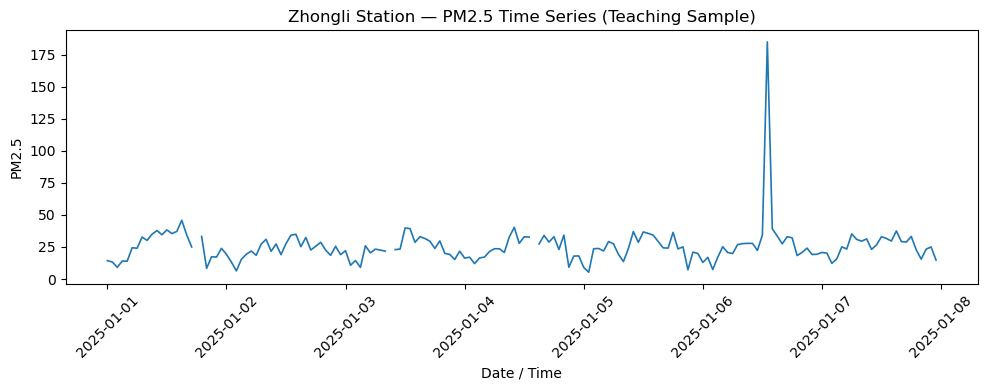

In [10]:
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['datetime'], df['PM2.5'], linewidth=1.2)
ax.set_title('Zhongli Station — PM2.5 Time Series (Teaching Sample)')
ax.set_xlabel('Date / Time')
ax.set_ylabel('PM2.5')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Interpretation and limitations

Write a short interpretation here. Describe the pattern shown in the figure, note any missing or suspicious values, and state what this small teaching sample cannot establish.

**AI-use record (if applicable):** State the tool, task, and how you verified the output.